<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/PIA_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

##################################################
##                                              ##
##             PRODUCTO INTEGRADOR              ##
##    Pronósticos en la Cadena de Suministro    ##
##                                              ##
##                                              ##
##  Saúl Roberto Morales Velázquez              ##
##  1856691                                     ##
##                                              ##
##################################################

#**Librerías**

In [47]:
from google.colab import files, userdata
from prophet import Prophet # Prophet de Meta (Facebook)
from prophet.plot import plot_plotly, plot_components_plotly  # Generador de gráficas de componentes de Meta Prophet.
import json # Permite trabajar con datos en formato JSON.
import numpy as np # Permite trabajar con opercaciones matemáticas avanzadas.
import pandas as pd # Permite trabajar con data frames.
import plotly.express as px # Librería que permite la creación de gráficas interactivas.
import plotly.graph_objects as go # Librería que permite la creación de gráficas interactivas.
import requests
from sklearn.metrics import mean_absolute_percentage_error as MAPE # Métricas de evaluación.

#**Funciones**

In [17]:
def seasonality_check(df: object, ds_name: str) :
  """
    Identifica la periodicidad de los datos en un DataFrame.

    Args:
        df (object): DataFrame que contiene los datos a analizar.
        ds_name (str): Nombre de la columna que contiene las fechas.

    Returns:
        dict: Diccionario con los parámetros booleanos de periodicidad.
  """

  # Parámetros por defecto
  day = False
  week = True
  month = True
  year = True

  # Revisa cuántos periodos contiene el dataframe.
  periods = min (
      (max(df[ds_name]) - min(df[ds_name])).days,
      df.shape[0]
  )

  if periods == 1 :
    day = True
  if periods < 7 :
    week = False
  if periods < 90 : # El rango de 90 días parece ser sugerido por el profesor.
    month = False
  if periods <= 365 :
    year = False

  dictionary = {  # Diccionario de valores booleanos con los parámetros.
      "day" : day,
      "week" : week,
      "month" : month,
      "year" : year
  }

  return dictionary

In [4]:
def real_plt(df: object, time_column_name: str, value_column_name: str, title: str, xaxis_title="Tiempo", yaxis_title="Ventas") :
  """
  Grafica la serie de tiempo con los datos reales.

  Args:
      df (object): DataFrame que contiene los datos a graficar.
      time_column_name (str): Nombre de la columna que contiene las fechas.
      value_column_name (str): Nombre de la columna que contiene los valores.
      title (str): Título de la gráfica.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = px.line(df, x=time_column_name, y=value_column_name, title=title)

  fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
      buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
      ])
    )
  )

  fig.update_layout(
    title = title,
    xaxis_title = "Tiempo",
    yaxis_title = "Tipo de cambio"
  )

  return fig.show()

In [7]:
def real_vs_forecast_plt(real_df: object, real_time_column_name: str, real_value_column_name: str, forecast_df: object, title: str, forecast_time_column_name = "ds", forecast_value_column_name = "yhat") :
  """
  Grafica la comparativa de las series de tiempo con los datos reales y pronosticados.

  Args:
      real_df (object): DataFrame que contiene los datos reales.
      real_time_column_name (str): Nombre de la columna que contiene las fechas de los datos reales.
      real_value_column_name (str): Nombre de la columna que contiene los valores reales.
      forecast_df (object): DataFrame que contiene los datos pronosticados.
      title (str): Título de la gráfica.
      forecast_time_column_name (str): Nombre de la columna que contiene las fechas de los datos pronosticados.
      forecast_value_column_name (str): Nombre de la columna que contiene los valores pronosticados.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = go.Figure()

  fig.add_trace(
      go.Scatter(
          x = forecast_df[forecast_time_column_name],
          y = forecast_df[forecast_value_column_name],
          name = "Prophet",
          line = dict(color = "#8C000F", width = 3, dash = "dash")
      )
  )

  fig.add_trace(
      go.Scatter(
          x = real_df[real_time_column_name],
          y = real_df[real_value_column_name],
          name = "Real",
          line = dict(color = "olive", width = 3, dash = "dash")
      )
  )

  fig.update_layout(
      title = title,
      xaxis_title = "Tiempo",
      yaxis_title = "Ventas"
  )

  return fig.show()

In [8]:
def difference_df(df: object, data_column_name: str) :
  """
  Permite obtener la diferencia entre cada fila de datos en elo data frame.

  Args:
      df (object): DataFrame.
      data_column_name (str): Nombre de la columna que contiene los valores.

  Returns:
      Object: DataFrame con la diferencia entre cada fila.
  """

  df_diff = df
  df_diff["diff"] = np.nan

  past_number = 0
  for index, row in df.iterrows():
    if index == 0:
      df_diff.at[index, "diff"] = 0
      past_number = row[data_column_name]
    else:
      df_diff.at[index, "diff"] = (float(row[data_column_name]) / float(past_number))-1
      past_number = row[data_column_name]

  return df

In [9]:
def get_spike_dates(df: object, date_column_name: str, difference_column_name="diff") :
  avg_diff = np.mean(abs(df[difference_column_name]))
  std_diff = np.std(abs(df[difference_column_name]))

  dates = []
  for index, row in df.iterrows():
    if abs(row[difference_column_name]) > avg_diff + 3*std_diff:
      dates.append(row[date_column_name])

  return dates

#**Clases**

In [20]:
class banxico() :
  def __init__(self, token: str) :
    self.token = token
    self.serie_ID = ""
    self.url = ""
    self.response = ""
    self.HTTP_status_code = 0
    self.HTTP_status = ""
    self.json_data = ""
    self.title = ""
    self.df = pd.DataFrame()

  def get_data(self, serie_ID: str) :
    import requests # Permite realizar peticiones HTML.
    HTTP_codes = {
      "200" : "OK",
      "400" : "Bad Request",
      "401" : "Unauthorized",
      "403" : "Forbidden",
      "404" : "Not Found",
      "500" : "Internal Server Error",
    }

    self.url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie_ID}/datos?token={self.token}"

    self.response = requests.get(self.url)
    self.HTTP_status_code = self.response.status_code
    self.HTTP_status = HTTP_codes[str(self.HTTP_status_code)]

    self.json_data = self.response.json()
    self.title = self.json_data["bmx"]["series"][0]["titulo"]
    self.df = pd.DataFrame(self.json_data["bmx"]["series"][0]["datos"])
    self.df["fecha"] = pd.to_datetime(self.df["fecha"], format="%d/%m/%Y")

    return self.df

#**Data frame**

In [54]:
# @title Texto de título predeterminado
banxico_serieID = "SF116766" # @param {"type":"string"}
data = banxico(userdata.get('Banxico_Token'))
df = data.get_data(banxico_serieID)
data.json_data

{'bmx': {'series': [{'idSerie': 'SF116766',
    'titulo': 'Valores Gubernamentales vendidos al público en general con el programa "Cetesdirecto", Tasa de descuento en Cetes a 28 días.',
    'datos': [{'fecha': '02/09/2010', 'dato': '4.46'},
     {'fecha': '09/09/2010', 'dato': '4.46'},
     {'fecha': '15/09/2010', 'dato': '4.43'},
     {'fecha': '07/10/2010', 'dato': '4.17'},
     {'fecha': '14/10/2010', 'dato': '4.04'},
     {'fecha': '21/10/2010', 'dato': '4.02'},
     {'fecha': '28/10/2010', 'dato': '3.83'},
     {'fecha': '04/11/2010', 'dato': '3.84'},
     {'fecha': '11/11/2010', 'dato': '3.91'},
     {'fecha': '18/11/2010', 'dato': 'N/E'},
     {'fecha': '25/11/2010', 'dato': 'N/E'},
     {'fecha': '02/12/2010', 'dato': '4.34'},
     {'fecha': '09/12/2010', 'dato': '4.15'},
     {'fecha': '16/12/2010', 'dato': '4.17'},
     {'fecha': '23/12/2010', 'dato': '4.37'},
     {'fecha': '30/12/2010', 'dato': '4.43'},
     {'fecha': '06/01/2011', 'dato': '4.15'},
     {'fecha': '13/01/201

#**Parámetros Prophet**

In [50]:
dictionary_seasonality = seasonality_check(df = df, ds_name = "fecha") # Revisa la periodicidad del dataframe.

ph_parameters = { # Genera diccionado con los parámetros utilizados por Prophet.
    "growth" : "linear",
    "changepoint_range" : 0.6,
    "interval_width" : 0.6,

    "daily_seasonality" : dictionary_seasonality["day"],
    "weekly_seasonality" : dictionary_seasonality["week"],
    # "monthly_seasonality" : dictionary_seasonality["month"],  # Parece que Prophet no requiere este parámetro.
    "yearly_seasonality" : dictionary_seasonality["year"],

    "seasonality_mode" : "multiplicative",
    "seasonality_prior_scale" : 1,
    # "holidays_prior_scale" : 1, # No estoy usando «vacaciones».
    "changepoint_prior_scale" : 1
}

dictionary_seasonality  # Muestra cuales son los parámetros de temporalidad que determinó el algoritmo.

{'day': False, 'week': True, 'month': True, 'year': True}

In [51]:
real_plt(df, "fecha", "dato", data.title, yaxis_title="Tipo de cambio")

#**Entrenamiento del modelo**

In [52]:
data_model = df.rename(columns={"fecha": "ds", "dato": "y"})  # Cambia el nombre de las columnas por aquellas que requiere Prophet para trabajar y crea un nuevo data frame con el nombre de estas columnas.

model = Prophet(**ph_parameters) # Crea un modelo de Prophet con los parámetros establecidos.
# model.add_seasonality(name='monthly', period=30.5, fourier_order=5) # Agrega temporalidad mensual al modelo.
model.fit(data_model) # Agrega los datos al modelo de Prophet.

future_dates = model.make_future_dataframe(periods=90, freq="d")  # Establece los parámetros para un pronóstico a 90 días.
forecast = model.predict(future_dates)  # Crea el propóstico.

ValueError: Unable to parse string "N/E" at position 9

In [36]:
real_vs_forecast_plt(real_df = df, real_time_column_name = "fecha", real_value_column_name = "dato", forecast_df = forecast, title="Ventas reales vs Prophet")  # Crea la gráfica comparativa de las ventas reales vs el pronóstico.
# model.plot(forecast)  # Crea la gráfica del forecast.
# plt.show()  # Muestra la gráfica del forecast.

#**Componentes**

In [40]:
forecast['ds'] = pd.to_datetime(forecast['ds']) # Asegura que las fechas en el forecast se muestren el formato ISO.

fig_comparative = plot_plotly(model, forecast)  # Gráfica d serie de tiempo combinada.

fig_comparative.update_layout(
  title = "Ventas reales vs Prophet",
  xaxis_title = "Tiempo",
  yaxis_title = "Ventas"
)

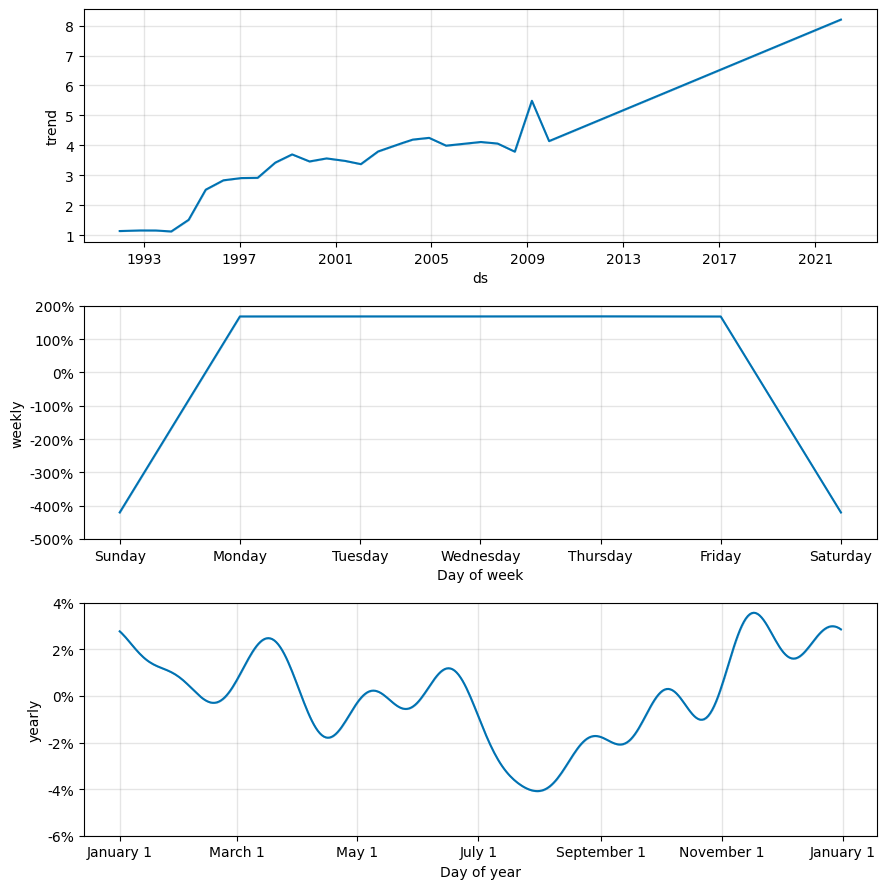

In [41]:
fig_components = model.plot_components(forecast); # Gráfica de componentes. Uso un punto y coma (;) para que solo se muestre la gráfica una vez.

#**MAPE**

In [45]:
mape_value = MAPE(data_model["y"], forecast.iloc[:-90]["yhat"]) * 100 # Función mean_absolute_percentage_error (MAPE) de sklearn
mape_value

4.1790305701408865

#**Descarga de datos**

In [48]:
forecast.to_csv("forecast.csv")
files.download("forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>